In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import os
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

np.random.seed(0)

# Projeto 3 de Algebra Linear Numérica

### 1. Redução à Forma de Hessenberg

**a) _Cálculo dos refletores_. Escreva uma função `to_hessemberg(A)` que calcula a forma de Hessemberg de uma matriz A usando refletores de Householder. A função deve retornar uma lista de refletores $v_i$, a matriz $H$ tal que $A = QHQ^∗$, e $Q$, que é a matriz ortogonal dada pelo produto dos refletores**

In [3]:
def sign(x):
    return -1 if x < 0 else 1

In [4]:
def to_hessenberg(A: np.ndarray) -> tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    """Função que recebe uma matriz A e calcula sua forma de Hessenberg.

    Args:
        A (np.ndarray): Matriz que será calculada

    Returns:
        tuple[list[np.ndarray], np.ndarray, np.ndarray]: Lista contendo os vetores de reflexão v_i, a matriz de
        Hessenberg e a matriz ortogonal Q
    """
    if A.shape[0] != A.shape[1]:
        raise ValueError("Você precisa passar uma matriz quadrada")

    M = A.copy()

    reflectors = []
    m = M.shape[0]
    Q = np.identity(m)

    for k in range(m-2):
        x = M[k+1:m, k].reshape(-1, 1)
        v_k = sign(x[0]) * np.linalg.norm(x) * np.eye(x.shape[0], 1) + x
        v_k = v_k / np.linalg.norm(v_k)
        M[k+1:m, k:m] -= 2 * v_k @ (v_k.T @ M[k+1:m, k:m])
        M[0:m, k+1:m] -= 2 * (M[0:m, k+1:m] @ v_k) @ v_k.T

        Q[k+1:m, k+1:m] @= v_k @ v_k.T

        reflectors.append(v_k)

    Q = np.eye(m)
    for k, v_k in enumerate(reflectors):
        H_k = np.eye(m)
        H_k[k + 1:m, k + 1:m] -= 2 * (v_k @ v_k.T)
        Q = Q @ H_k

    return reflectors, M, Q

**b\) Verifique que sua função de fato está correta, calculando $\|A −QHQ^∗\|$ e $\|Q^∗Q −I\|$ para diversas matrizes A: use simétricas e não simétricas, e de diferentes tamanhos**

In [5]:
normal_matrices = [np.random.random_sample((m, m)) for m in range(2, 100)]
matrices_to_symetrize = [np.random.random_sample((m, m)) for m in range(2, 100)]
symetric_matrices = []
for matrix in matrices_to_symetrize:
    m = (matrix + matrix.T)/2
    symetric_matrices.append(m)

In [6]:
normal_hessenbergs = [to_hessenberg(m) for m in normal_matrices]
symetric_hessenbergs = [to_hessenberg(m) for m in symetric_matrices]

In [7]:
norms_difference_normals = []
norms_difference_symetrics = []

identities_difference_normals = []
identities_difference_symetrics = []

for i in range(len(normal_hessenbergs)):
    # Adicionando das matrizes comuns
    norm_normal = np.linalg.norm(
        normal_matrices[i] - normal_hessenbergs[i][2] @ normal_hessenbergs[i][1] @ normal_hessenbergs[i][2].T
    )
    norms_difference_normals.append(norm_normal)

    # Adicionando das matrizes simétricas
    norm_symetric = np.linalg.norm(
        symetric_matrices[i] - symetric_hessenbergs[i][2] @ symetric_hessenbergs[i][1] @ symetric_hessenbergs[i][2].T
    )
    norms_difference_symetrics.append(norm_symetric)


    # Adicionando das matrizes comuns
    identity_difference_normal = np.linalg.norm(
        np.identity(i+2) - normal_hessenbergs[i][2].T @ normal_hessenbergs[i][2]
    )
    identities_difference_normals.append(identity_difference_normal)

    # Adicionando das matrizes simétricas
    identity_difference_symetric = np.linalg.norm(
        np.identity(i+2) - symetric_hessenbergs[i][2].T @ symetric_hessenbergs[i][2]
    )
    identities_difference_symetrics.append(identity_difference_symetric)

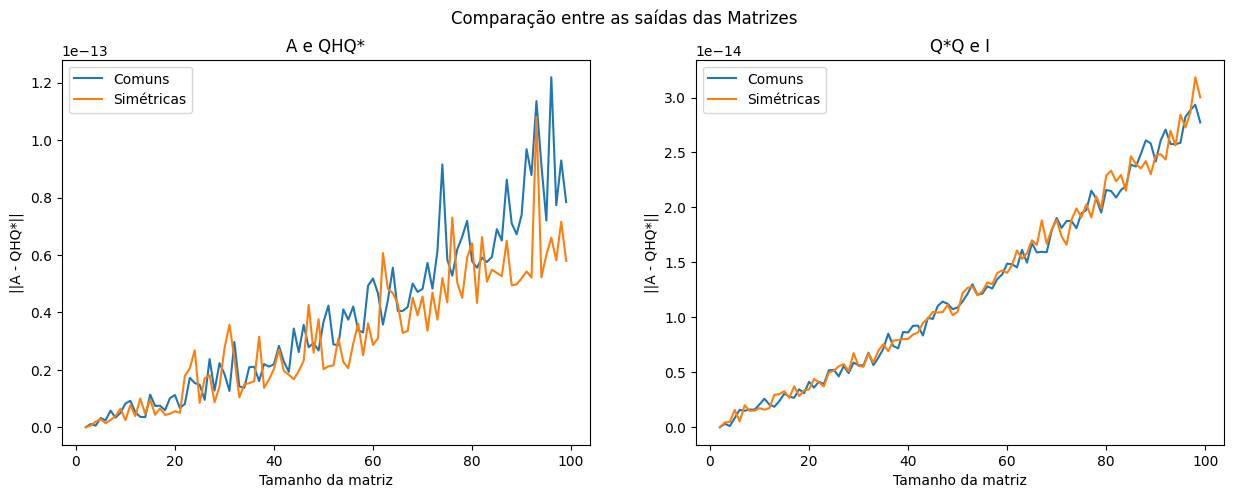

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Comparação entre as saídas das Matrizes")

axes[0].set_title("A e QHQ*")
axes[1].set_title("Q*Q e I")

axes[0].plot(range(2, 100), norms_difference_normals, label="Comuns")
axes[0].plot(range(2, 100), norms_difference_symetrics, label="Simétricas")

axes[1].plot(range(2, 100), identities_difference_normals, label="Comuns")
axes[1].plot(range(2, 100), identities_difference_symetrics, label="Simétricas")

axes[0].set_xlabel("Tamanho da matriz")
axes[0].set_ylabel("||A - QHQ*||")
axes[1].set_xlabel("Tamanho da matriz")
axes[1].set_ylabel("||A - QHQ*||")

axes[0].legend()
axes[1].legend()
plt.show()

Aqui podemos ver que a função está retornando matrizes satisfatórias

**c) _Complexidade_. Realize testes para matrizes n ×n, com n variando de 10 até 1000 (ou mais, se o seu computador aguentar!). Quanto tempo seu algoritmo leva para calcular a forma de Hessemberg? Para matrizes pequenas, repita o teste até levar pelo menos 1 segundo, para evitar erros de medida de tempos muito pequenos. Qual parece ser a complexidade observada do algoritmo?**

O código abaixo faz o teste de execução da função `to_hessenberg` para matrizes indo de 10 até 1000 variando de 50 em 50 nos tamanhos. Esse código não deve ser executado caso junto do notebook tenha um arquivo chamado `hessenberg_execution_time.csv`, tendo em vista que ele armazena os resultados dessas funções para evitar a necessidade de executar e esperar as células terminarem a execução toda a vez que uma mudança for realizada

In [9]:
n = 1701
# sizes = [*range(10, 101, 5), *range(150, 200, 50), *range(500, 601, 20), *range(800, 901, 20), 1000]
sizes = [*range(2000, 5001, 1000)]
registered_times_exist = os.path.exists("registered_times.csv")

In [10]:
normal_times = []


def calculate_normal_matrix(size):
    total_time = 0
    count = 0
    
    matrix = np.random.random_sample((size, size))  # Gero a matriz

    while total_time < 1:
        count += 1
        initial = time.perf_counter()  # Inicio o contador de performance
        _, _, _ = to_hessenberg(matrix)  # Executo a função da matriz de hessenberg
        finish = time.perf_counter()  # Finalizo o contador

        performance = finish-initial

        total_time += performance

    return total_time / count


if not registered_times_exist:    
    for size in sizes:
        print(f"Calculando {size}x{size}")
        normal_times.append(calculate_normal_matrix(size))

In [11]:
symmetric_times = []

def calculate_symetric_matrix(size):
    matrix = np.random.random_sample((size, size))
    matrix = (matrix + matrix.T) / 2
    total_time = 0
    count = 0

    while total_time < 1:
        count += 1
        initial = time.perf_counter()  # Inicio o contador de performance
        _, _, _ = to_hessenberg(matrix)  # Executo a função da matriz de hessenberg
        finish = time.perf_counter()  # Finalizo o contador

        performance = finish-initial

        total_time += performance

    return total_time / count


if not registered_times_exist:
    for i in sizes:
        print(f"Calculando {i}x{i}")
        symmetric_times.append(calculate_symetric_matrix(i))

In [12]:
if registered_times_exist:
    df = pd.read_csv("registered_times.csv")
    normal_times = df["TIME_NORMAL"]
    symmetric_times = df["TIME_SYMMETRIC"]
    sizes = df["SIZES"]

Fazendo uma análise na função que eu fiz, é possível ver que a complexidade do algoritmo é $O(n^3)$. Vejamos:
```py
for k in range(m-2):                                                    # Tenho m-2 iterações => O(m)
    v_k = sign(x[0]) * np.linalg.norm(x) * np.eye(x.shape[0], 1) + x    # O(m)
    v_k = v_k / np.linalg.norm(v_k)                                     # O(m)
    M[k+1:m, k:m] -= 2 * v_k @ (v_k.T @ M[k+1:m, k:m])                  # O(m^2)
    M[0:m, k+1:m] -= 2 * (M[0:m, k+1:m] @ v_k) @ v_k.T                  # O(m^2)

    Q[k+1:m, k+1:m] @= v_k @ v_k.T                                      # O(m^2)

Q = np.eye(m)
for k, v_k in enumerate(reflectors):                                    # O(m)
    H_k = np.eye(m)
    H_k[k + 1:m, k + 1:m] -= 2 * (v_k @ v_k.T)                          # O(m^2)
    Q = Q @ H_k                                                         # O(m^2)
```

Chegamos então que:
$$
O(m)(O(2m) + O(3m^2)) + O(m)(O(2m^2)) = O(m^3)
$$

Certo, teoricamente o algoritmo é $O(m^3)$, mas isso vale mesmo na prática?

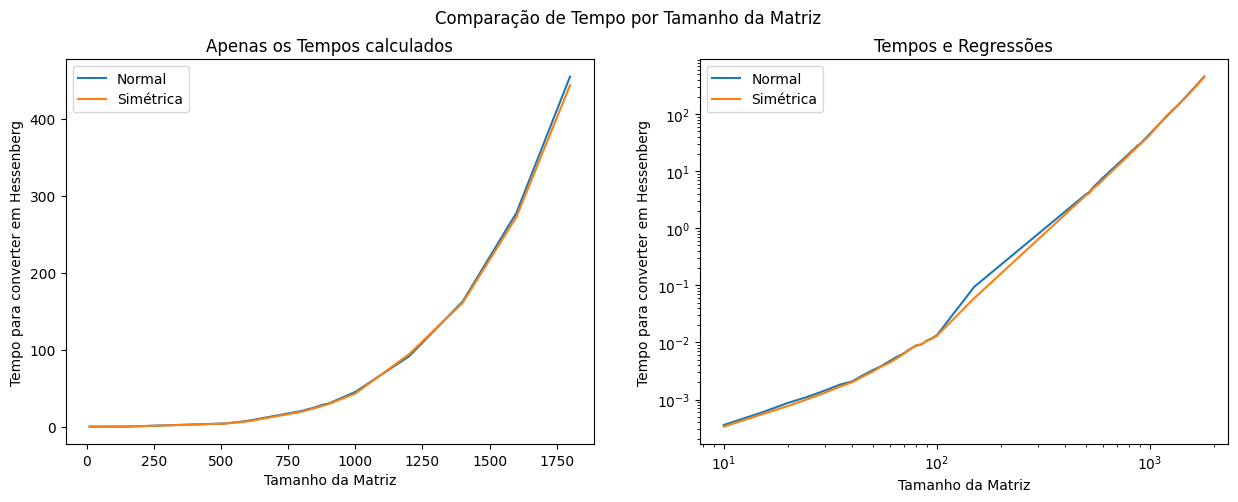

np.float64(2.7877218130105024)

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fig.suptitle("Comparação de Tempo por Tamanho da Matriz")
axes[0].plot(sizes, normal_times, label="Normal")
axes[0].plot(sizes, symmetric_times, label="Simétrica")
axes[1].loglog(sizes, normal_times, label="Normal")
axes[1].loglog(sizes, symmetric_times, label="Simétrica")

axes[0].set_title("Apenas os Tempos calculados")
axes[1].set_title("Tempos e Regressões")

inclination_sum = 0

for j in range(len(sizes)-1):
    inclination_j = (np.log(normal_times[j+1]) - np.log(normal_times[j]))/(np.log(sizes[j+1]) - np.log(sizes[j]))
    inclination_sum += inclination_j

inclination_average = inclination_sum/(len(sizes)-2)

axes[0].set_ylabel("Tempo para converter em Hessenberg")
axes[0].set_xlabel("Tamanho da Matriz")
axes[1].set_ylabel("Tempo para converter em Hessenberg")
axes[1].set_xlabel("Tamanho da Matriz")
axes[0].legend()
axes[1].legend()

plt.show()
inclination_average

In [14]:
df = pd.DataFrame(columns=['TIME_NORMAL', 'TIME_SYMMETRIC', 'SIZES'])
df['TIME_NORMAL'] = pd.Series(normal_times)
df['TIME_SYMMETRIC'] = pd.Series(symmetric_times)
df['SIZES'] = pd.Series(sizes)

df.to_csv('times.csv', index=False)